# PATRIC Database Exploration

This notebook explores the PATRIC (Pathosystems Resource Integration Center) data for AMR prediction modeling.

**Contents:**
1. Load and inspect raw PATRIC data
2. Analyze genome metadata
3. Explore AMR phenotype distributions
4. Analyze antibiotic resistance patterns
5. Explore sequence characteristics
6. Visualize processed features
7. Baseline model evaluation

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Paths
PATRIC_DIR = Path('../data/raw/patric')
PROCESSED_DIR = Path('../data/processed/patric')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Raw PATRIC Data

In [2]:
# Load AMR phenotypes
amr_phenotypes = pd.read_csv(PATRIC_DIR / 'amr_phenotypes.csv')
print(f"AMR Phenotypes: {len(amr_phenotypes)} entries")
print(f"Columns: {list(amr_phenotypes.columns)}")

AMR Phenotypes: 12745 entries
Columns: ['antibiotic', 'genome_name', 'evidence', 'computational_method', 'owner', 'computational_method_performance', 'public', 'measurement', 'taxon_id', 'genome_id', 'measurement_value', 'measurement_unit', 'computational_method_version', 'id', 'date_inserted', 'date_modified', '_version_', 'resistant_phenotype', 'laboratory_typing_method', 'pmid', 'laboratory_typing_platform', 'measurement_sign', 'vendor', 'testing_standard', 'testing_standard_year']


In [3]:
amr_phenotypes.head(10)

,antibiotic,genome_name,evidence,computational_method,owner,computational_method_performance,public,measurement,taxon_id,genome_id,...,date_modified,_version_,resistant_phenotype,laboratory_typing_method,pmid,laboratory_typing_platform,measurement_sign,vendor,testing_standard,testing_standard_year
0,trimethoprim/sulfamethoxazole,Escherichia coli W,Computational Method,MIC XGBoost Model,PATRIC@patricbrc.org,"W1 score: 0.81, CI[0.76, 0.85]",True,128.0,566546,566546.53,...,2025-07-14T21:11:15.037Z,1840540449767424000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,trimethoprim/sulfamethoxazole,Escherichia coli W,Computational Method,SIR XGBoost Model,PATRIC@patricbrc.org,"F1 score: 0.94, CI[0.94, 0.95]",True,NaN,566546,566546.53,...,2025-07-14T21:46:54.279Z,1840540479339364400,Resistant,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,amoxicillin/clavulanic acid,Escherichia coli W,Computational Method,MIC XGBoost Model,PATRIC@patricbrc.org,"W1 score: 0.97, CI[0.96, 0.98]",True,4.0,566546,566546.53,...,2025-07-14T21:11:15.064Z,1837658264958926800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,amikacin,Escherichia coli W,Computational Method,MIC XGBoost Model,PATRIC@patricbrc.org,"W1 score: 0.97, CI[0.96, 0.98]",True,2.0,566546,566546.53,...,2025-07-14T21:11:15.064Z,1837658264958926800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ampicillin,Escherichia coli W,Computational Method,MIC XGBoost Model,PATRIC@patricbrc.org,"W1 score: 0.87, CI[0.82, 0.92]",True,8.0,566546,566546.53,...,2025-07-14T21:11:15.064Z,1837658264958926800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,aztreonam,Escherichia coli W,Computational Method,MIC XGBoost Model,PATRIC@patricbrc.org,"W1 score: 0.61, CI[0.50, 0.73]",True,2.0,566546,566546.53,...,2025-07-14T21:11:15.064Z,1837658264958926800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ceftazidime,Escherichia coli W,Computational Method,MIC XGBoost Model,PATRIC@patricbrc.org,"W1 score: 0.88, CI[0.86, 0.90]",True,4.0,566546,566546.53,...,2025-07-14T21:11:15.064Z,1837658264958926800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,cefazolin,Escherichia coli W,Computational Method,MIC XGBoost Model,PATRIC@patricbrc.org,"W1 score: 0.86, CI[0.82, 0.90]",True,16.0,566546,566546.53,...,2025-07-14T21:11:15.064Z,1837658264958926800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,chloramphenicol,Escherichia coli W,Computational Method,MIC XGBoost Model,PATRIC@patricbrc.org,"W1 score: 0.77, CI[0.71, 0.83]",True,16.0,566546,566546.53,...,2025-07-14T21:11:15.064Z,1837658264958926800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ciprofloxacin,Escherichia coli W,Computational Method,MIC XGBoost Model,PATRIC@patricbrc.org,"W1 score: 0.95, CI[0.93, 0.97]",True,0.25,566546,566546.53,...,2025-07-14T21:11:15.064Z,1837658264958926800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Load genome metadata
genomes_metadata = pd.read_csv(PATRIC_DIR / 'genomes_metadata.csv')
print(f"Genome Metadata: {len(genomes_metadata)} entries")
print(f"Columns: {list(genomes_metadata.columns)}")

Genome Metadata: 2000 entries
Columns: ['assembly_accession', 'bioproject_accession', 'biosample_accession', 'cell_shape', 'class', 'common_name', 'completion_date', 'contigs', 'culture_collection', 'date_inserted', 'date_modified', 'family', 'gc_content', 'genbank_accessions', 'genome_id', 'genome_length', 'genome_name', 'genome_status', 'genus', 'gram_stain', 'habitat', 'kingdom', 'motility', 'order', 'owner', 'oxygen_requirement', 'patric_cds', 'phylum', 'plasmids', 'public', 'publication', 'refseq_cds', 'sequencing_centers', 'species', 'strain', 'taxon_id', 'temperature_range', 'superkingdom', 'cds', 'sequencing_status', 'taxon_lineage_ids', 'comments', 'taxon_lineage_names', '_version_', 'contig_n50', 'hypothetical_cds_ratio', 'contig_l50', 'rrna', 'partial_cds_ratio', 'lab_host', 'trna', 'chromosomes', 'host_name', 'cds_ratio', 'partial_cds', 'plfam_cds_ratio', 'disease', 'checkm_completeness', 'checkm_contamination', 'coarse_consistency', 'fine_consistency', 'genome_quality', 'h

In [5]:
genomes_metadata.head()

,assembly_accession,bioproject_accession,biosample_accession,cell_shape,class,common_name,completion_date,contigs,culture_collection,date_inserted,...,body_sample_site,antimicrobial_resistance,host_age,host_gender,other_environmental,salinity,reference_genome,longitude,latitude,isolation_site
0,GCA_000184185.1,PRJNA48011,SAMN02602978,Bacilli,Gammaproteobacteria,Escherichia_coli_W,2016-07-25T00:00:00Z,1,ATCC:9637,2017-12-29T21:45:17.926Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GCA_000184185.1,PRJNA48011,SAMN02602978,Bacilli,Gammaproteobacteria,Escherichia_coli_W,2016-07-25T00:00:00Z,1,ATCC:9637,2017-12-29T21:45:18.042Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,Escherichia_coli_phage_EH297,2003-03-03T00:00:00Z,1,NaN,2025-12-07T19:02:09.291Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GCA_000027125.1,PRJEA40647,SAMEA2272277,Bacilli,Gammaproteobacteria,Escherichia_coli_042,2016-07-25T00:00:00Z,1,NaN,2017-12-30T06:13:22.076Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GCA_000529855.1,PRJEB4814,SAMEA3138867,NaN,Gammaproteobacteria,Escherichia_coli_ISC7,NaN,196,NaN,2014-12-08T22:11:27.515Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Load download summary if available
summary_file = PATRIC_DIR / 'download_summary.json'
if summary_file.exists():
    with open(summary_file) as f:
        download_summary = json.load(f)
    print("Download Summary:")
    for key, value in download_summary.items():
        print(f"  {key}: {value}")

Download Summary:
  total_with_amr: 289
  downloaded: 271
  failed: 18
  failed_ids: [562.53161, 562.4746, 83333.39, 562.4822, 562.476, 562.4768, 562.474, 72407.17, 93062.6, 1074919.2, 282459.2, 400667.8, 470.2588, 470.2589, 470.259, 509173.2, 1096996.1, 470.2848]


In [7]:
# Count genome FASTA files
genomes_dir = PATRIC_DIR / 'genomes'
if genomes_dir.exists():
    fasta_files = list(genomes_dir.glob('*.fasta'))
    print(f"Genome FASTA files: {len(fasta_files)}")
    
    # Sample file sizes
    file_sizes = [f.stat().st_size for f in fasta_files[:50]]
    print(f"Sample file sizes (first 50): min={min(file_sizes):,} bytes, max={max(file_sizes):,} bytes")

Genome FASTA files: 271
Sample file sizes (first 50): min=1,492 bytes, max=5,323,597 bytes


In [8]:
# Basic statistics
print("=== PATRIC Database Statistics ===")
print(f"Total AMR phenotype records: {len(amr_phenotypes):,}")
print(f"Unique genomes in AMR data: {amr_phenotypes['genome_id'].nunique():,}")
print(f"Unique antibiotics: {amr_phenotypes['antibiotic'].nunique()}")
print(f"Genome metadata records: {len(genomes_metadata):,}")
print(f"Genome FASTA files: {len(fasta_files)}")

=== PATRIC Database Statistics ===
Total AMR phenotype records: 12,745
Unique genomes in AMR data: 384
Unique antibiotics: 52
Genome metadata records: 2,000
Genome FASTA files: 271


## 2. Genome Metadata Analysis

In [9]:
# Species distribution
if 'species' in genomes_metadata.columns:
    species_counts = genomes_metadata['species'].value_counts()
    print(f"Unique species: {len(species_counts)}")
    print("\nTop 15 species:")
    print(species_counts.head(15))

Unique species: 6

Top 15 species:
species
Klebsiella pneumoniae           500
Staphylococcus aureus           500
Acinetobacter baumannii         500
Escherichia coli                498
Escherichia coli phage EH297      1
Escherichia coli phage phiS       1
Name: count, dtype: int64


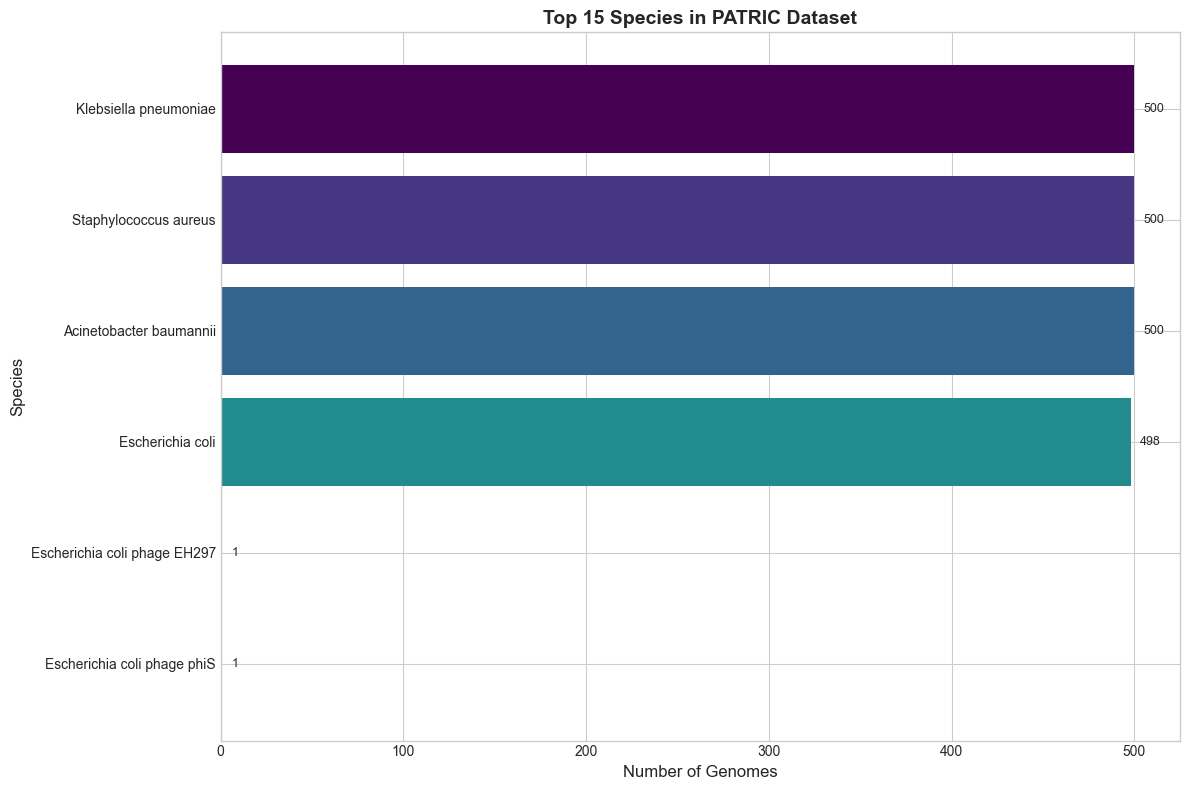

In [10]:
# Visualize species distribution
fig, ax = plt.subplots(figsize=(12, 8))

top_species = species_counts.head(15)
colors = plt.cm.viridis(np.linspace(0, 0.8, len(top_species)))

bars = ax.barh(range(len(top_species)), top_species.values, color=colors)
ax.set_yticks(range(len(top_species)))
ax.set_yticklabels(top_species.index)
ax.set_xlabel('Number of Genomes', fontsize=12)
ax.set_ylabel('Species', fontsize=12)
ax.set_title('Top 15 Species in PATRIC Dataset', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for bar, count in zip(bars, top_species.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

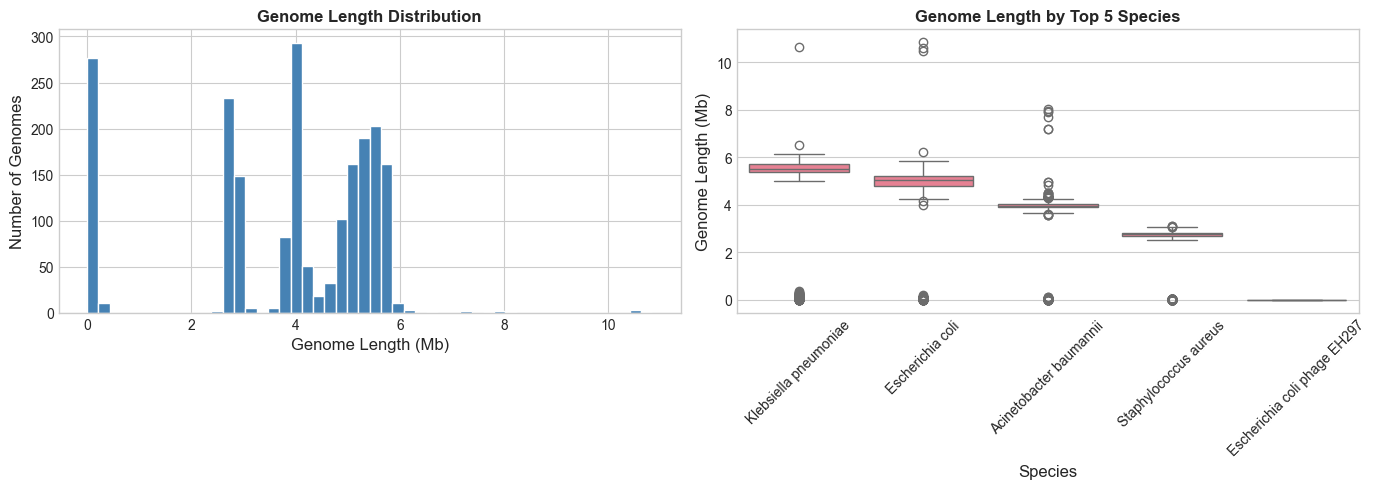


Genome length statistics (Mb):
count    2000.000000
mean        3.803184
std         1.852289
min         0.001037
25%         2.807990
50%         4.036789
75%         5.287175
max        10.844348
Name: genome_length, dtype: float64


In [11]:
# Genome length distribution
if 'genome_length' in genomes_metadata.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    genome_lengths = genomes_metadata['genome_length'].dropna() / 1e6  # Convert to Mb
    axes[0].hist(genome_lengths, bins=50, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('Genome Length (Mb)', fontsize=12)
    axes[0].set_ylabel('Number of Genomes', fontsize=12)
    axes[0].set_title('Genome Length Distribution', fontsize=12, fontweight='bold')
    
    # Box plot by species
    top_5_species = species_counts.head(5).index.tolist()
    species_lengths = genomes_metadata[genomes_metadata['species'].isin(top_5_species)]
    species_lengths = species_lengths[['species', 'genome_length']].dropna()
    species_lengths['genome_length'] = species_lengths['genome_length'] / 1e6
    
    species_order = species_lengths.groupby('species')['genome_length'].median().sort_values(ascending=False).index
    sns.boxplot(data=species_lengths, x='species', y='genome_length', order=species_order, ax=axes[1])
    axes[1].set_xlabel('Species', fontsize=12)
    axes[1].set_ylabel('Genome Length (Mb)', fontsize=12)
    axes[1].set_title('Genome Length by Top 5 Species', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nGenome length statistics (Mb):")
    print(genome_lengths.describe())

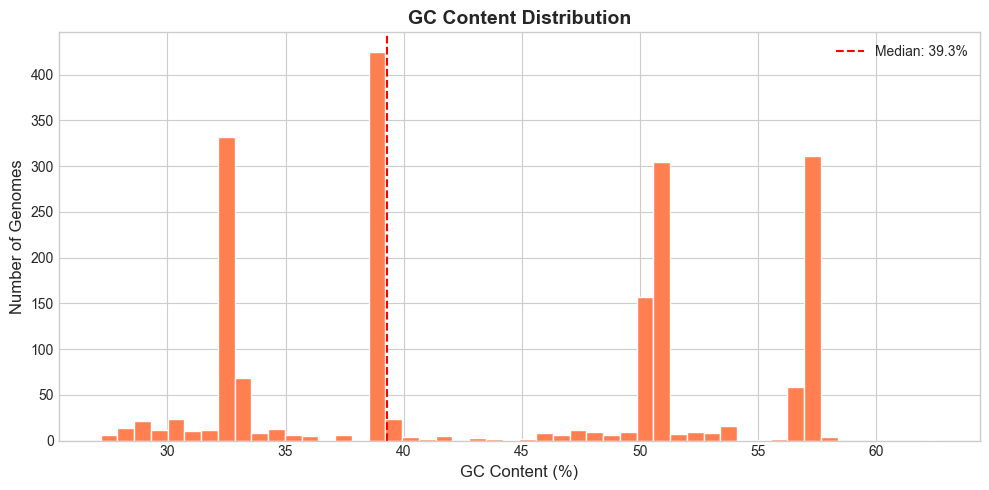

GC content statistics:
count    1935.000000
mean       44.042199
std         9.510452
min        27.170000
25%        32.978947
50%        39.300000
75%        50.800000
max        62.627743
Name: gc_content, dtype: float64


In [12]:
# GC content distribution if available
if 'gc_content' in genomes_metadata.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    gc_content = genomes_metadata['gc_content'].dropna()
    ax.hist(gc_content, bins=50, color='coral', edgecolor='white')
    ax.set_xlabel('GC Content (%)', fontsize=12)
    ax.set_ylabel('Number of Genomes', fontsize=12)
    ax.set_title('GC Content Distribution', fontsize=14, fontweight='bold')
    ax.axvline(gc_content.median(), color='red', linestyle='--', label=f'Median: {gc_content.median():.1f}%')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"GC content statistics:")
    print(gc_content.describe())

## 3. AMR Phenotype Analysis

In [13]:
# Phenotype distribution
phenotype_counts = amr_phenotypes['resistant_phenotype'].value_counts()
print("Phenotype Distribution:")
print(phenotype_counts)

Phenotype Distribution:
resistant_phenotype
Susceptible    3514
Resistant      1326
Name: count, dtype: int64


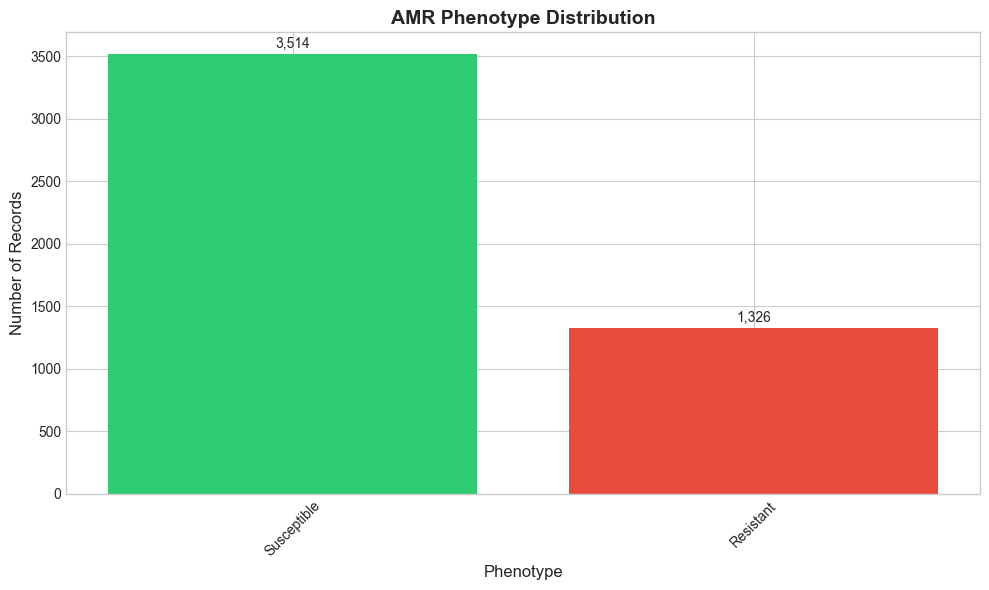

In [14]:
# Visualize phenotype distribution
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#3498db']
bars = ax.bar(phenotype_counts.index, phenotype_counts.values, color=colors[:len(phenotype_counts)])
ax.set_xlabel('Phenotype', fontsize=12)
ax.set_ylabel('Number of Records', fontsize=12)
ax.set_title('AMR Phenotype Distribution', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

# Add count labels
for bar, count in zip(bars, phenotype_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
# Filter to Resistant/Susceptible only for modeling
amr_rs = amr_phenotypes[amr_phenotypes['resistant_phenotype'].isin(['Resistant', 'Susceptible'])].copy()
print(f"Records with R/S phenotype: {len(amr_rs):,}")
print(f"\nR/S breakdown:")
print(amr_rs['resistant_phenotype'].value_counts())

Records with R/S phenotype: 4,840

R/S breakdown:
resistant_phenotype
Susceptible    3514
Resistant      1326
Name: count, dtype: int64


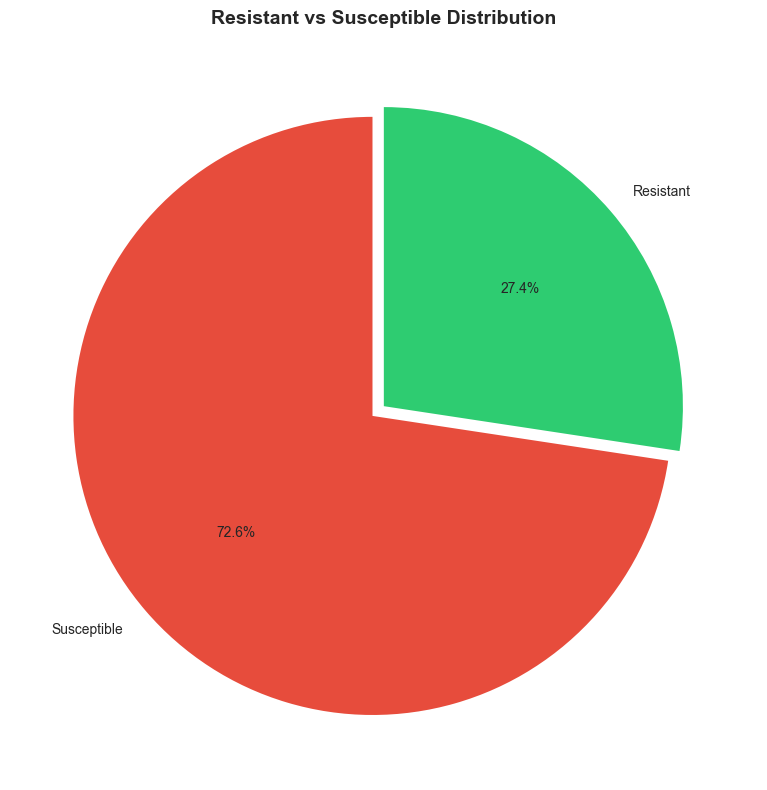

In [16]:
# R/S ratio pie chart
fig, ax = plt.subplots(figsize=(8, 8))

rs_counts = amr_rs['resistant_phenotype'].value_counts()
colors = ['#e74c3c', '#2ecc71']  # Red for Resistant, Green for Susceptible
wedges, texts, autotexts = ax.pie(
    rs_counts.values,
    labels=rs_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=(0.05, 0),
    startangle=90
)
ax.set_title('Resistant vs Susceptible Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Antibiotic Distribution Analysis

In [17]:
# Antibiotic distribution
antibiotic_counts = amr_rs['antibiotic'].value_counts()
print(f"Unique antibiotics: {len(antibiotic_counts)}")
print("\nTop 20 antibiotics:")
print(antibiotic_counts.head(20))

Unique antibiotics: 40

Top 20 antibiotics:
antibiotic
trimethoprim/sulfamethoxazole    270
ciprofloxacin                    270
tetracycline                     270
gentamicin                       270
cefoxitin                        188
imipenem                         177
tobramycin                       168
levofloxacin                     168
meropenem                        168
ampicillin/sulbactam             163
ceftazidime                      163
erythromycin                     102
penicillin                       102
methicillin                      102
clindamycin                      102
oxacillin                         98
fusidic acid                      98
daptomycin                        98
ertapenem                         90
cefepime                          90
Name: count, dtype: int64


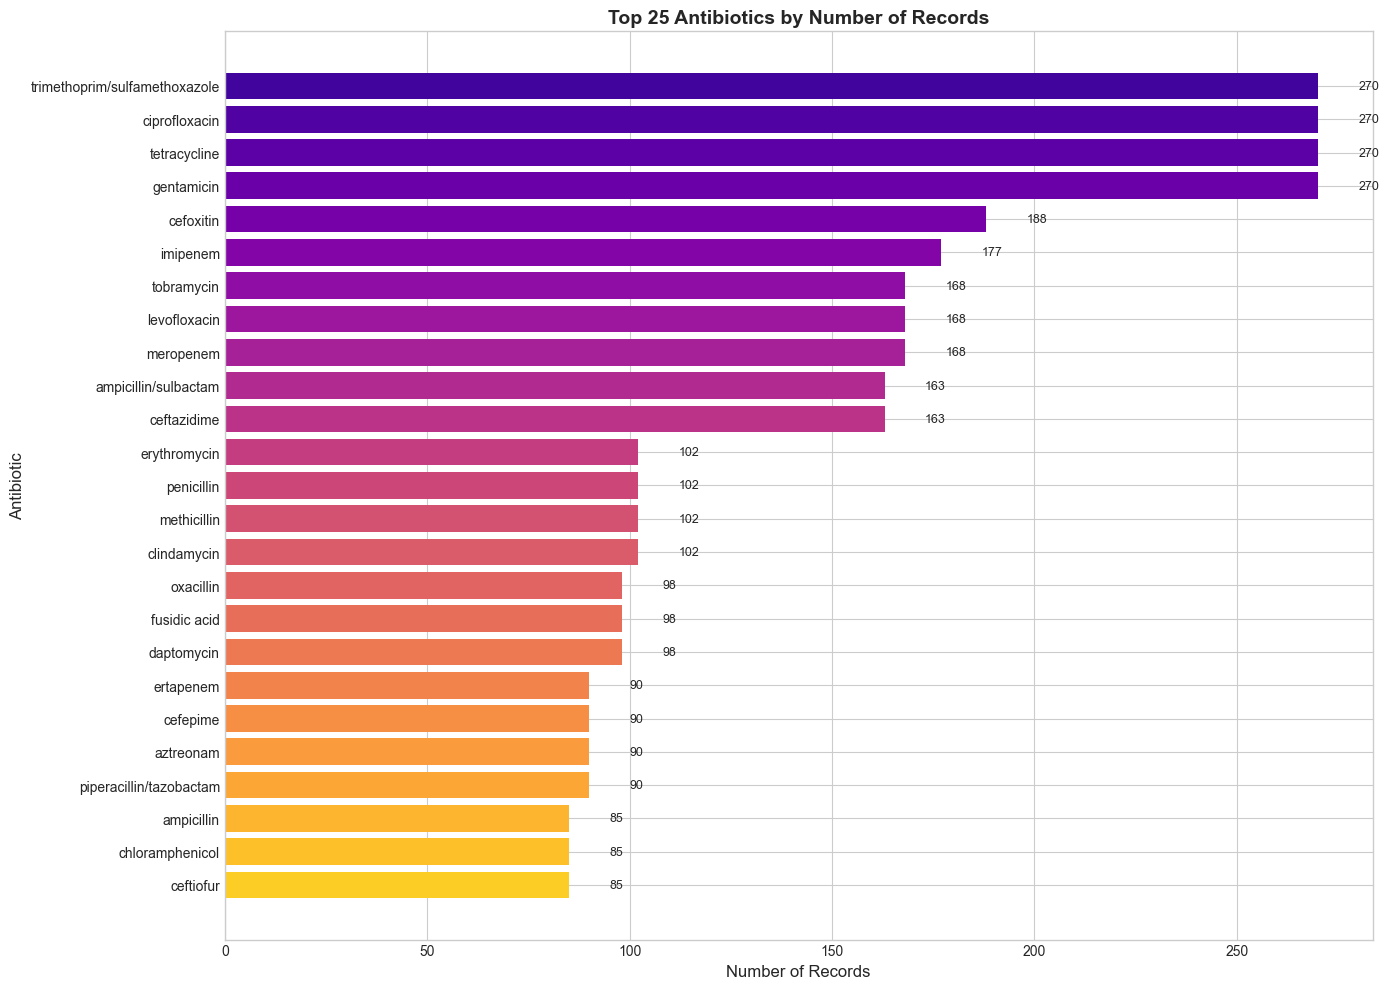

In [18]:
# Visualize antibiotic distribution
fig, ax = plt.subplots(figsize=(14, 10))

top_antibiotics = antibiotic_counts.head(25)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(top_antibiotics)))

bars = ax.barh(range(len(top_antibiotics)), top_antibiotics.values, color=colors)
ax.set_yticks(range(len(top_antibiotics)))
ax.set_yticklabels(top_antibiotics.index)
ax.set_xlabel('Number of Records', fontsize=12)
ax.set_ylabel('Antibiotic', fontsize=12)
ax.set_title('Top 25 Antibiotics by Number of Records', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for bar, count in zip(bars, top_antibiotics.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
# Calculate resistance rate per antibiotic
resistance_stats = []
for ab in amr_rs['antibiotic'].unique():
    ab_data = amr_rs[amr_rs['antibiotic'] == ab]
    r_count = (ab_data['resistant_phenotype'] == 'Resistant').sum()
    s_count = (ab_data['resistant_phenotype'] == 'Susceptible').sum()
    total = r_count + s_count
    r_rate = r_count / total if total > 0 else 0
    
    resistance_stats.append({
        'antibiotic': ab,
        'resistant': r_count,
        'susceptible': s_count,
        'total': total,
        'resistance_rate': r_rate
    })

resistance_df = pd.DataFrame(resistance_stats).sort_values('total', ascending=False)
print("Resistance Statistics (Top 20):")
resistance_df.head(20)

Resistance Statistics (Top 20):


,antibiotic,resistant,susceptible,total,resistance_rate
0,trimethoprim/sulfamethoxazole,57,213,270,0.211111
9,ciprofloxacin,97,173,270,0.359259
26,tetracycline,62,208,270,0.229630
17,gentamicin,85,185,270,0.314815
16,cefoxitin,37,151,188,0.196809
18,imipenem,43,134,177,0.242938
29,tobramycin,21,147,168,0.125000
19,levofloxacin,49,119,168,0.291667
20,meropenem,24,144,168,0.142857
23,ampicillin/sulbactam,16,147,163,0.098160


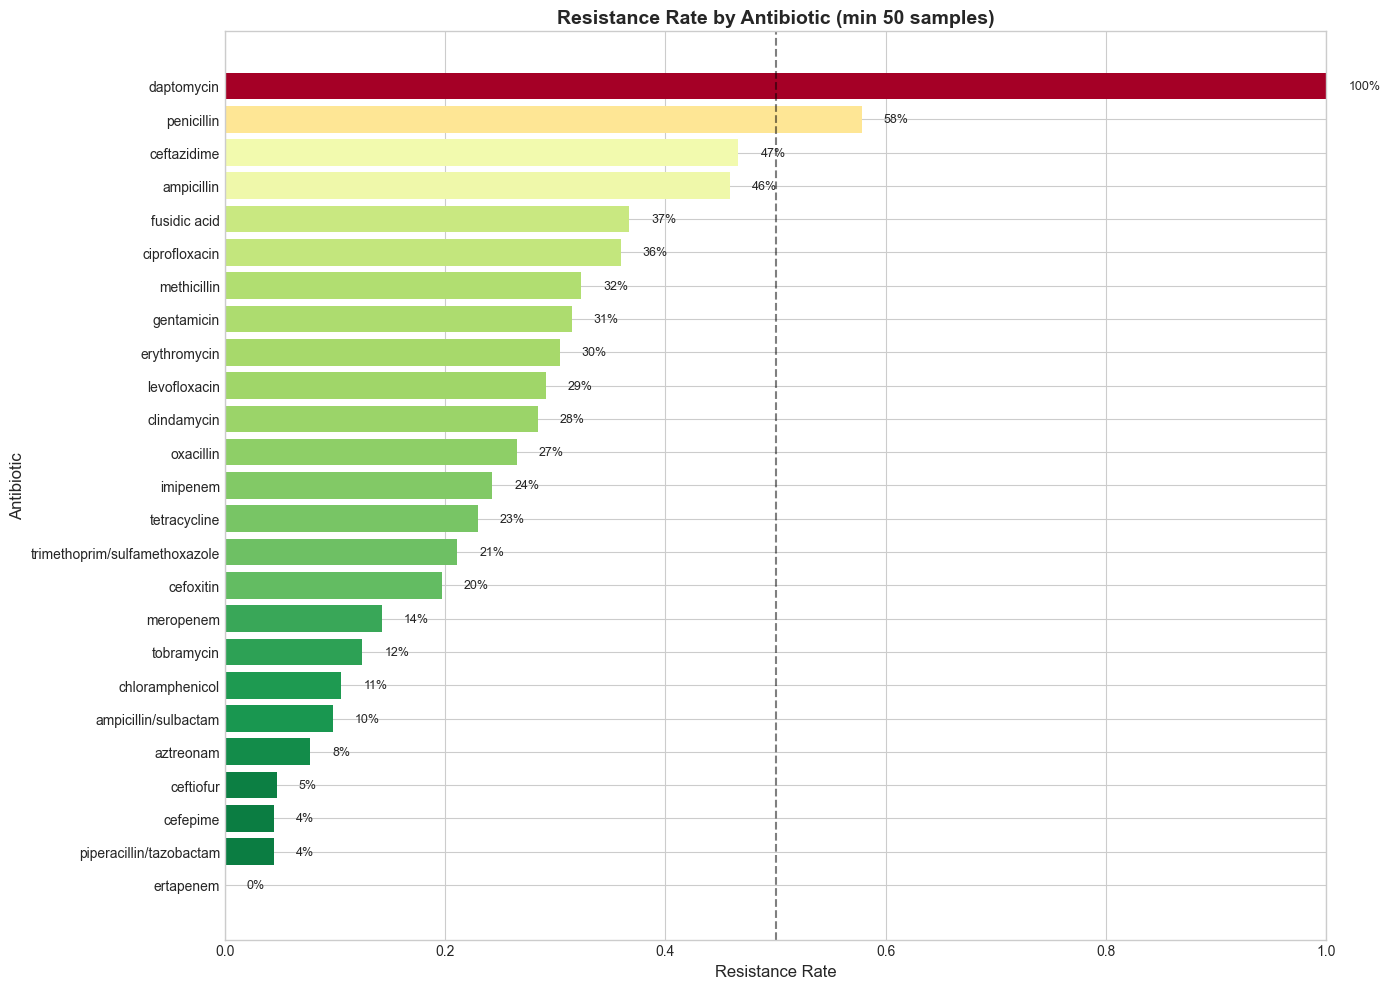

In [20]:
# Visualize resistance rates
fig, ax = plt.subplots(figsize=(14, 10))

# Filter to antibiotics with at least 50 samples
top_ab = resistance_df[resistance_df['total'] >= 50].head(25).copy()
top_ab = top_ab.sort_values('resistance_rate', ascending=True)

colors = plt.cm.RdYlGn_r(top_ab['resistance_rate'].values)

bars = ax.barh(range(len(top_ab)), top_ab['resistance_rate'].values, color=colors)
ax.set_yticks(range(len(top_ab)))
ax.set_yticklabels(top_ab['antibiotic'].values)
ax.set_xlabel('Resistance Rate', fontsize=12)
ax.set_ylabel('Antibiotic', fontsize=12)
ax.set_title('Resistance Rate by Antibiotic (min 50 samples)', fontsize=14, fontweight='bold')
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
ax.set_xlim(0, 1)

# Add percentage labels
for bar, rate in zip(bars, top_ab['resistance_rate'].values):
    ax.text(rate + 0.02, bar.get_y() + bar.get_height()/2,
            f'{rate:.0%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

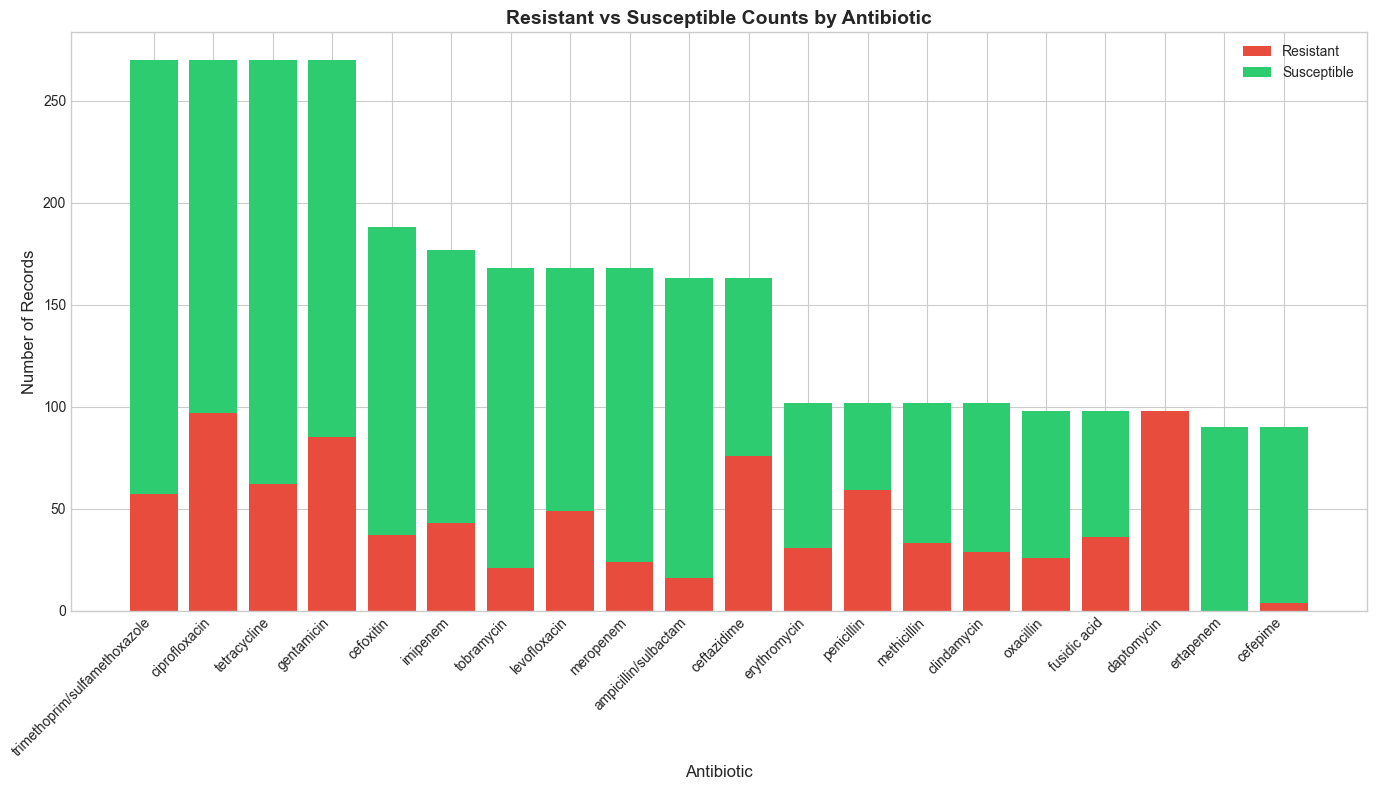

In [21]:
# Stacked bar chart showing R vs S for top antibiotics
fig, ax = plt.subplots(figsize=(14, 8))

top_20 = resistance_df.head(20).copy()
x = range(len(top_20))
width = 0.8

# Create stacked bars
ax.bar(x, top_20['resistant'], width, label='Resistant', color='#e74c3c')
ax.bar(x, top_20['susceptible'], width, bottom=top_20['resistant'], label='Susceptible', color='#2ecc71')

ax.set_xlabel('Antibiotic', fontsize=12)
ax.set_ylabel('Number of Records', fontsize=12)
ax.set_title('Resistant vs Susceptible Counts by Antibiotic', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_20['antibiotic'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Resistance by Organism Analysis

In [22]:
# Merge AMR data with genome metadata
amr_with_species = amr_rs.merge(
    genomes_metadata[['genome_id', 'species']].drop_duplicates(),
    on='genome_id',
    how='left'
)
print(f"Records with species info: {amr_with_species['species'].notna().sum():,}")

Records with species info: 4,840


In [23]:
# Resistance rate by species
species_resistance = []
for species in amr_with_species['species'].dropna().unique():
    sp_data = amr_with_species[amr_with_species['species'] == species]
    r_count = (sp_data['resistant_phenotype'] == 'Resistant').sum()
    s_count = (sp_data['resistant_phenotype'] == 'Susceptible').sum()
    total = r_count + s_count
    r_rate = r_count / total if total > 0 else 0
    
    species_resistance.append({
        'species': species,
        'resistant': r_count,
        'susceptible': s_count,
        'total': total,
        'resistance_rate': r_rate
    })

species_df = pd.DataFrame(species_resistance).sort_values('total', ascending=False)
print("Resistance by Species (Top 15):")
species_df.head(15)

Resistance by Species (Top 15):


,species,resistant,susceptible,total,resistance_rate
0,Escherichia coli,471,2164,2635,0.178748
2,Staphylococcus aureus,396,812,1208,0.327815
3,Acinetobacter baumannii,434,493,927,0.468177
1,Klebsiella pneumoniae,25,45,70,0.357143


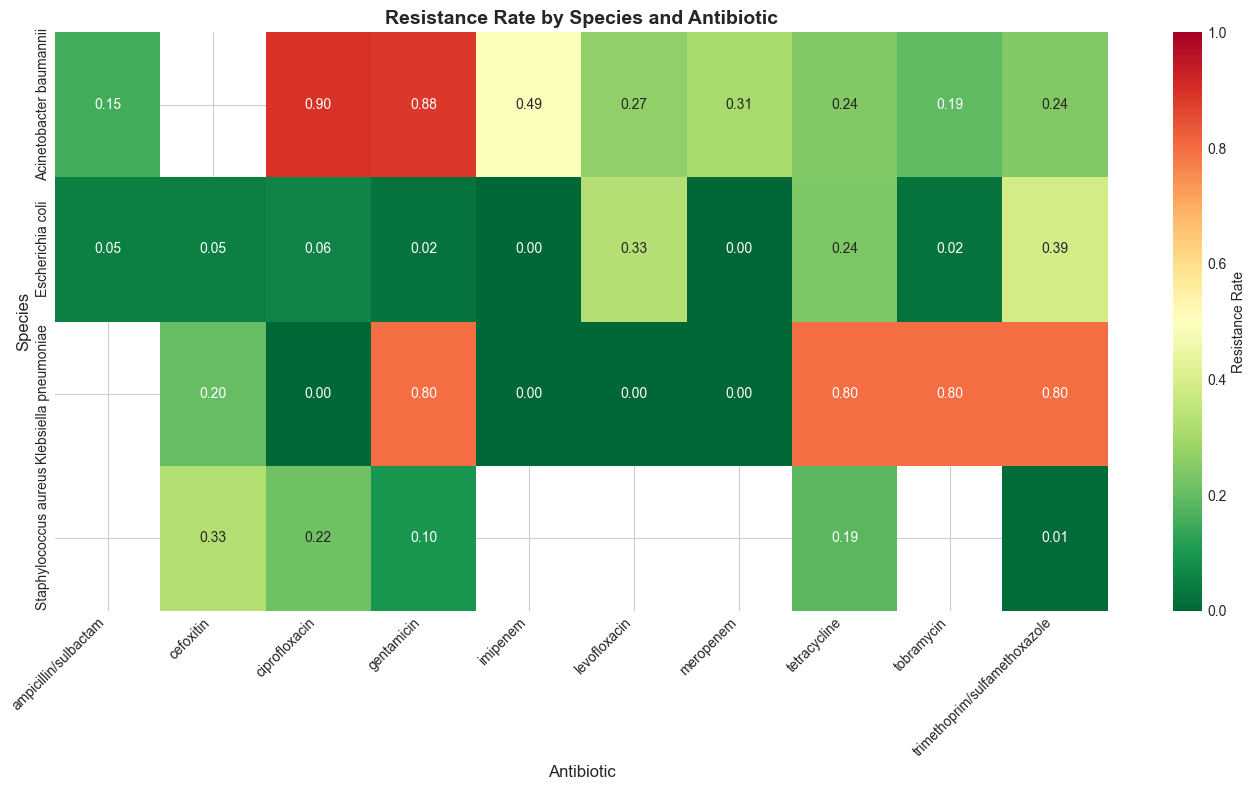

In [24]:
# Heatmap of resistance rate by species and antibiotic
top_5_species = species_df.head(5)['species'].tolist()
top_10_antibiotics = resistance_df[resistance_df['total'] >= 50].head(10)['antibiotic'].tolist()

# Create crosstab
filtered_data = amr_with_species[
    (amr_with_species['species'].isin(top_5_species)) &
    (amr_with_species['antibiotic'].isin(top_10_antibiotics))
]

# Calculate resistance rate for each combination
heatmap_data = []
for species in top_5_species:
    for ab in top_10_antibiotics:
        combo = filtered_data[
            (filtered_data['species'] == species) &
            (filtered_data['antibiotic'] == ab)
        ]
        if len(combo) > 0:
            r_rate = (combo['resistant_phenotype'] == 'Resistant').sum() / len(combo)
        else:
            r_rate = np.nan
        heatmap_data.append({'species': species, 'antibiotic': ab, 'resistance_rate': r_rate})

heatmap_df = pd.DataFrame(heatmap_data)
heatmap_pivot = heatmap_df.pivot(index='species', columns='antibiotic', values='resistance_rate')

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0.5,
            vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Resistance Rate'})
ax.set_title('Resistance Rate by Species and Antibiotic', fontsize=14, fontweight='bold')
ax.set_xlabel('Antibiotic', fontsize=12)
ax.set_ylabel('Species', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Sequence Characteristics

In [25]:
# Load a sample of sequences to analyze
from src.preprocessing.patric_preprocessor import PATRICPreprocessor

preprocessor = PATRICPreprocessor(
    patric_dir=str(PATRIC_DIR),
    output_dir=str(PROCESSED_DIR)
)
preprocessor.load_data()

print(f"Loaded {len(preprocessor.sequences)} genome sequences")

INFO:src.preprocessing.patric_preprocessor:Loading PATRIC data...
INFO:src.preprocessing.patric_preprocessor:Loaded 12745 AMR phenotype records
INFO:src.preprocessing.patric_preprocessor:Loaded 2000 genome metadata records
INFO:src.preprocessing.patric_preprocessor:Found 271 genome FASTA files
INFO:src.preprocessing.patric_preprocessor:Loaded sequences for 271 genomes


Loaded 271 genome sequences


In [26]:
# Get sequence statistics
seq_stats = preprocessor.get_sequence_statistics()
print("Sequence Statistics:")
seq_stats.head(10)

Sequence Statistics:


,genome_id,length,gc_content,a_count,t_count,g_count,c_count,n_count,other_count
183,585395.4,5524860,0.5063,1364066,1363333,1394221,1403240,0,0
162,72407.1693,5493096,0.5680,1184358,1188667,1558303,1561768,0,0
71,72407.1705,5493096,0.5680,1184358,1188667,1558303,1561768,0,0
233,1308539.8,5362708,0.5738,1143117,1142471,1538082,1539038,0,0
146,216592.3,5355323,0.5054,1324377,1324286,1348864,1357796,0,0
126,585397.9,5329142,0.5070,1313869,1313422,1345443,1356308,100,0
37,562.48227,5257805,0.5084,1290942,1293983,1340382,1332498,0,0
263,585055.8,5227344,0.5059,1292698,1289948,1319065,1325633,0,0
111,655817.3,5132961,0.5058,1271415,1265086,1297762,1298697,1,0
161,316435.61,5064230,0.5057,1253577,1249450,1278181,1282922,100,0


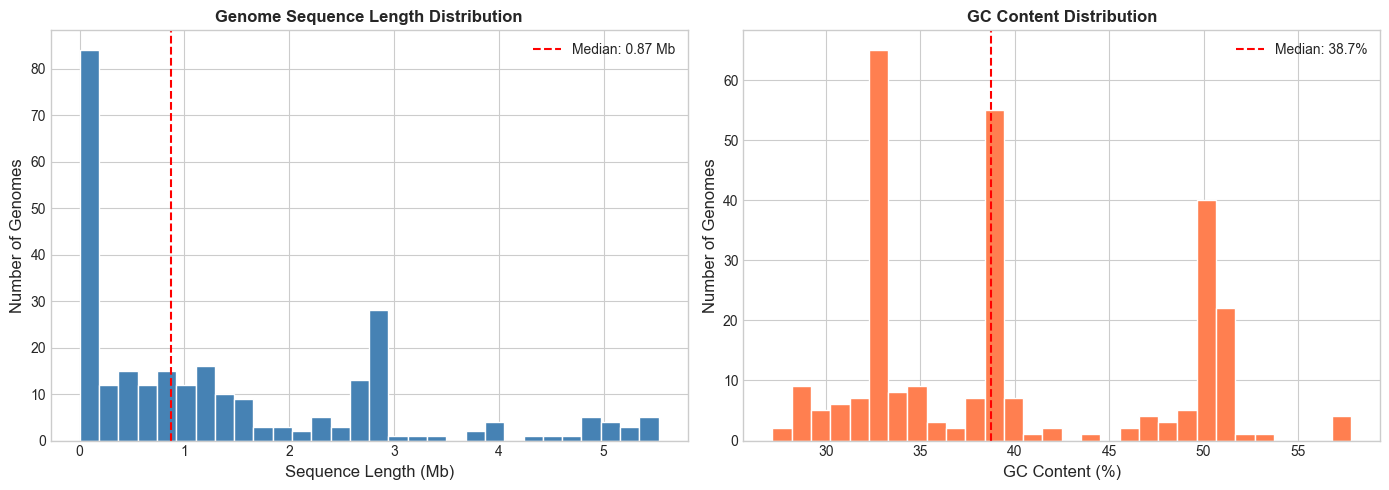


Sequence length statistics (Mb):
  Min: 0.00
  Max: 5.52
  Mean: 1.39
  Median: 0.87


In [27]:
# Sequence length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Length histogram
lengths_mb = seq_stats['length'] / 1e6
axes[0].hist(lengths_mb, bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Sequence Length (Mb)', fontsize=12)
axes[0].set_ylabel('Number of Genomes', fontsize=12)
axes[0].set_title('Genome Sequence Length Distribution', fontsize=12, fontweight='bold')
axes[0].axvline(lengths_mb.median(), color='red', linestyle='--', label=f'Median: {lengths_mb.median():.2f} Mb')
axes[0].legend()

# GC content histogram
axes[1].hist(seq_stats['gc_content'] * 100, bins=30, color='coral', edgecolor='white')
axes[1].set_xlabel('GC Content (%)', fontsize=12)
axes[1].set_ylabel('Number of Genomes', fontsize=12)
axes[1].set_title('GC Content Distribution', fontsize=12, fontweight='bold')
axes[1].axvline(seq_stats['gc_content'].median() * 100, color='red', linestyle='--',
                label=f'Median: {seq_stats["gc_content"].median()*100:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nSequence length statistics (Mb):")
print(f"  Min: {lengths_mb.min():.2f}")
print(f"  Max: {lengths_mb.max():.2f}")
print(f"  Mean: {lengths_mb.mean():.2f}")
print(f"  Median: {lengths_mb.median():.2f}")

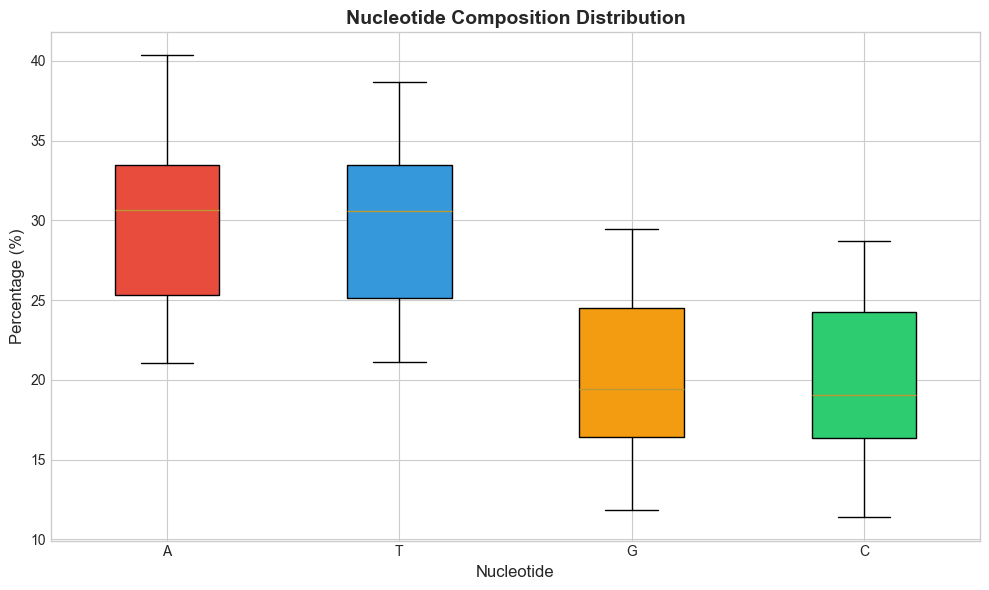

In [29]:
# Nucleotide composition
nucleotide_fractions = seq_stats[['a_count', 't_count', 'g_count', 'c_count']].copy()
for col in nucleotide_fractions.columns:
    nucleotide_fractions[col] = nucleotide_fractions[col] / seq_stats['length']

fig, ax = plt.subplots(figsize=(10, 6))

positions = range(len(nucleotide_fractions.columns))
bp = ax.boxplot([nucleotide_fractions[col] * 100 for col in nucleotide_fractions.columns],
                patch_artist=True)

colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticklabels(['A', 'T', 'G', 'C'])
ax.set_xlabel('Nucleotide', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Nucleotide Composition Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Processed Features Exploration

In [30]:
# Load processed multilabel data
X_train = np.load(PROCESSED_DIR / 'patric_multilabel_X_train.npy')
X_val = np.load(PROCESSED_DIR / 'patric_multilabel_X_val.npy')
X_test = np.load(PROCESSED_DIR / 'patric_multilabel_X_test.npy')
y_train = np.load(PROCESSED_DIR / 'patric_multilabel_y_train.npy')
y_val = np.load(PROCESSED_DIR / 'patric_multilabel_y_val.npy')
y_test = np.load(PROCESSED_DIR / 'patric_multilabel_y_test.npy')

with open(PROCESSED_DIR / 'patric_multilabel_metadata.json') as f:
    metadata = json.load(f)

print("=== Processed Data Statistics ===")
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features (k-mers): {X_train.shape[1]}")
print(f"Number of antibiotics: {y_train.shape[1]}")
print(f"k-mer size: {metadata.get('k', 'N/A')}")
print(f"Task type: {metadata['task_type']}")

=== Processed Data Statistics ===
Training samples: 189
Validation samples: 27
Test samples: 55
Number of features (k-mers): 500
Number of antibiotics: 37
k-mer size: 6
Task type: multilabel


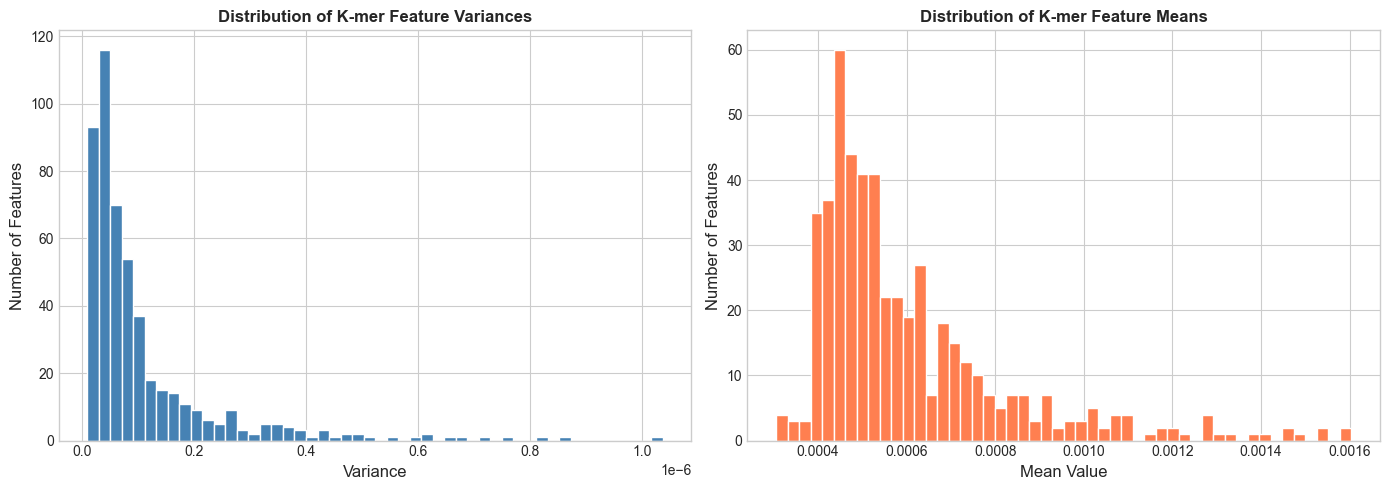

In [31]:
# Feature distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature variance
feature_var = np.var(X_train, axis=0)
axes[0].hist(feature_var, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Variance', fontsize=12)
axes[0].set_ylabel('Number of Features', fontsize=12)
axes[0].set_title('Distribution of K-mer Feature Variances', fontsize=12, fontweight='bold')

# Feature means
feature_mean = np.mean(X_train, axis=0)
axes[1].hist(feature_mean, bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Mean Value', fontsize=12)
axes[1].set_ylabel('Number of Features', fontsize=12)
axes[1].set_title('Distribution of K-mer Feature Means', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
# Top k-mer features by variance
feature_names = metadata.get('feature_names', [])
top_var_idx = np.argsort(feature_var)[::-1][:20]

print("Top 20 most variable k-mer features:")
for i, idx in enumerate(top_var_idx, 1):
    kmer = feature_names[idx] if idx < len(feature_names) else f'kmer_{idx}'
    print(f"{i:2d}. {kmer}: variance = {feature_var[idx]:.8f}")

Top 20 most variable k-mer features:
 1. AAAAAA: variance = 0.00000104
 2. TAAAAA: variance = 0.00000086
 3. AAAAAT: variance = 0.00000082
 4. TTTTAA: variance = 0.00000075
 5. TTTTTA: variance = 0.00000073
 6. TTTAAA: variance = 0.00000067
 7. TTAAAA: variance = 0.00000066
 8. TTTTTT: variance = 0.00000062
 9. ATAAAA: variance = 0.00000061
10. TTTTAT: variance = 0.00000059
11. ATTTTT: variance = 0.00000056
12. AAAATT: variance = 0.00000051
13. TATTTT: variance = 0.00000050
14. ATTTTA: variance = 0.00000048
15. AAAATA: variance = 0.00000048
16. AATTTT: variance = 0.00000048
17. AATAAA: variance = 0.00000046
18. TTATTT: variance = 0.00000043
19. TTTATT: variance = 0.00000042
20. AAAAAG: variance = 0.00000042


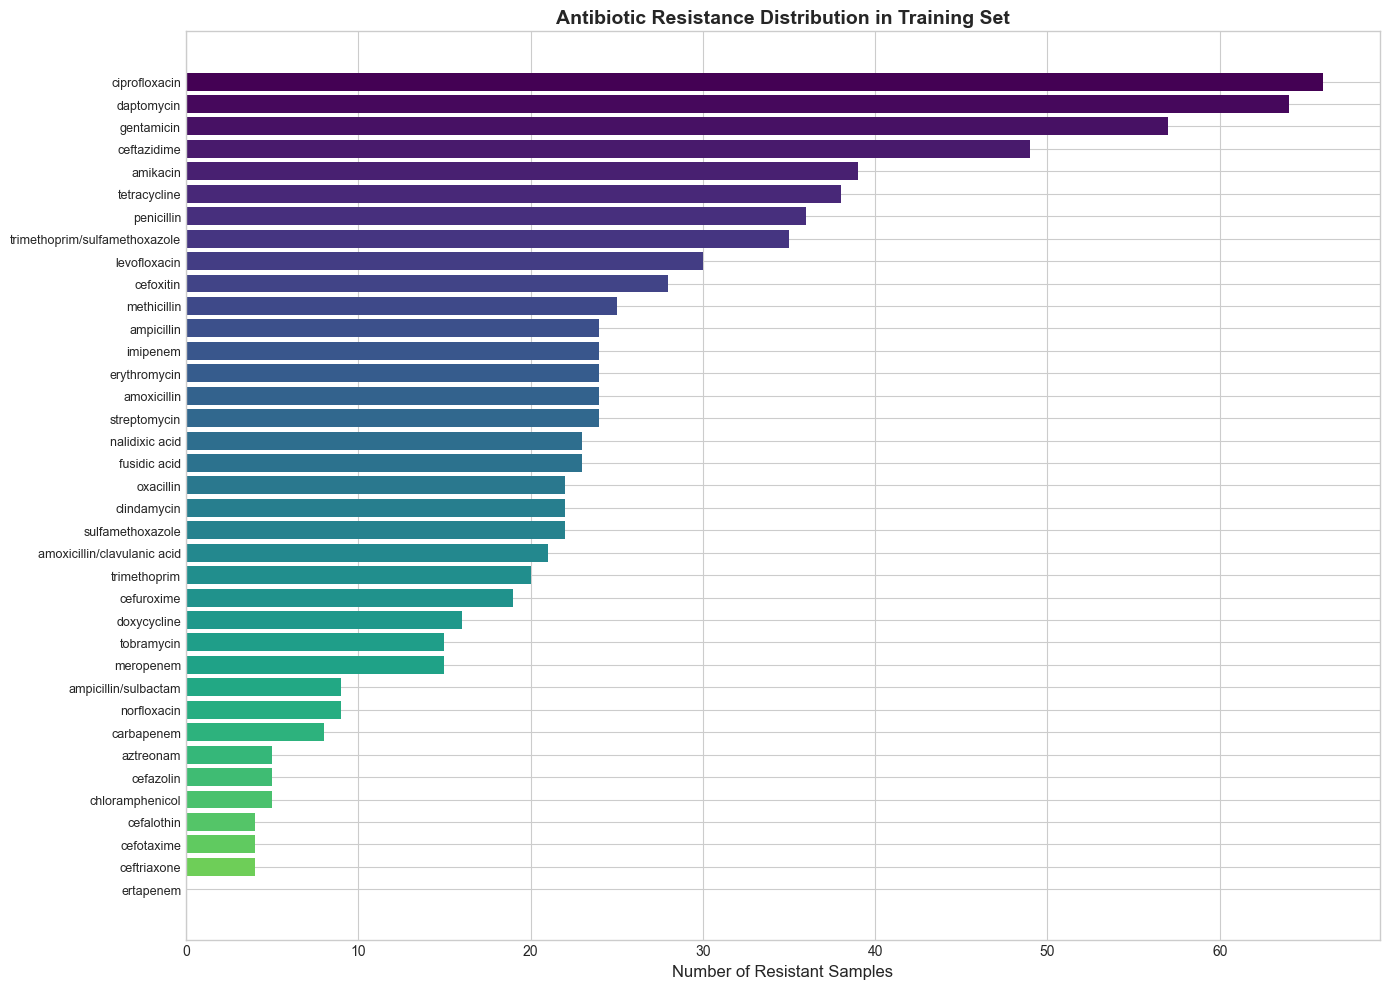

In [33]:
# Label distribution (antibiotics)
class_names = metadata.get('class_names', metadata.get('antibiotics', []))
label_counts = y_train.sum(axis=0)

fig, ax = plt.subplots(figsize=(14, 10))

sorted_idx = np.argsort(label_counts)[::-1]
sorted_counts = label_counts[sorted_idx]
sorted_names = [class_names[i] if i < len(class_names) else f'class_{i}' for i in sorted_idx]

colors = plt.cm.viridis(np.linspace(0, 0.8, len(sorted_counts)))
bars = ax.barh(range(len(sorted_counts)), sorted_counts, color=colors)
ax.set_yticks(range(len(sorted_counts)))
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('Number of Resistant Samples', fontsize=12)
ax.set_title('Antibiotic Resistance Distribution in Training Set', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

Average antibiotics tested per genome: 4.54
Max antibiotics tested: 21
Min antibiotics tested: 0


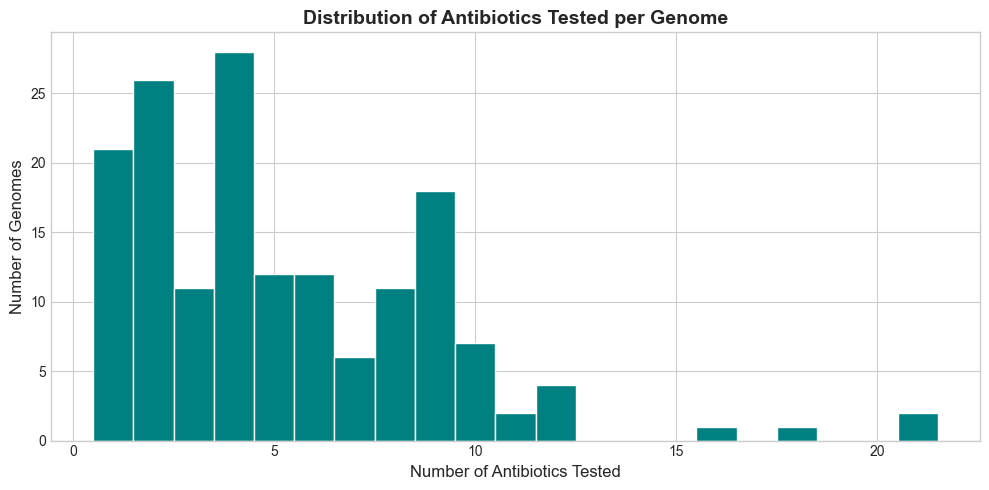

In [34]:
# Multi-label statistics
labels_per_sample = y_train.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(labels_per_sample, bins=range(1, int(labels_per_sample.max()) + 2),
        color='teal', edgecolor='white', align='left')
ax.set_xlabel('Number of Antibiotics Tested', fontsize=12)
ax.set_ylabel('Number of Genomes', fontsize=12)
ax.set_title('Distribution of Antibiotics Tested per Genome', fontsize=14, fontweight='bold')

print(f"Average antibiotics tested per genome: {labels_per_sample.mean():.2f}")
print(f"Max antibiotics tested: {labels_per_sample.max():.0f}")
print(f"Min antibiotics tested: {labels_per_sample.min():.0f}")

plt.tight_layout()
plt.show()

## 8. Dimensionality Reduction Visualization

In [35]:
from sklearn.decomposition import PCA

# PCA visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

PCA explained variance ratio: [0.6105096  0.08416503]
Total variance explained: 69.47%


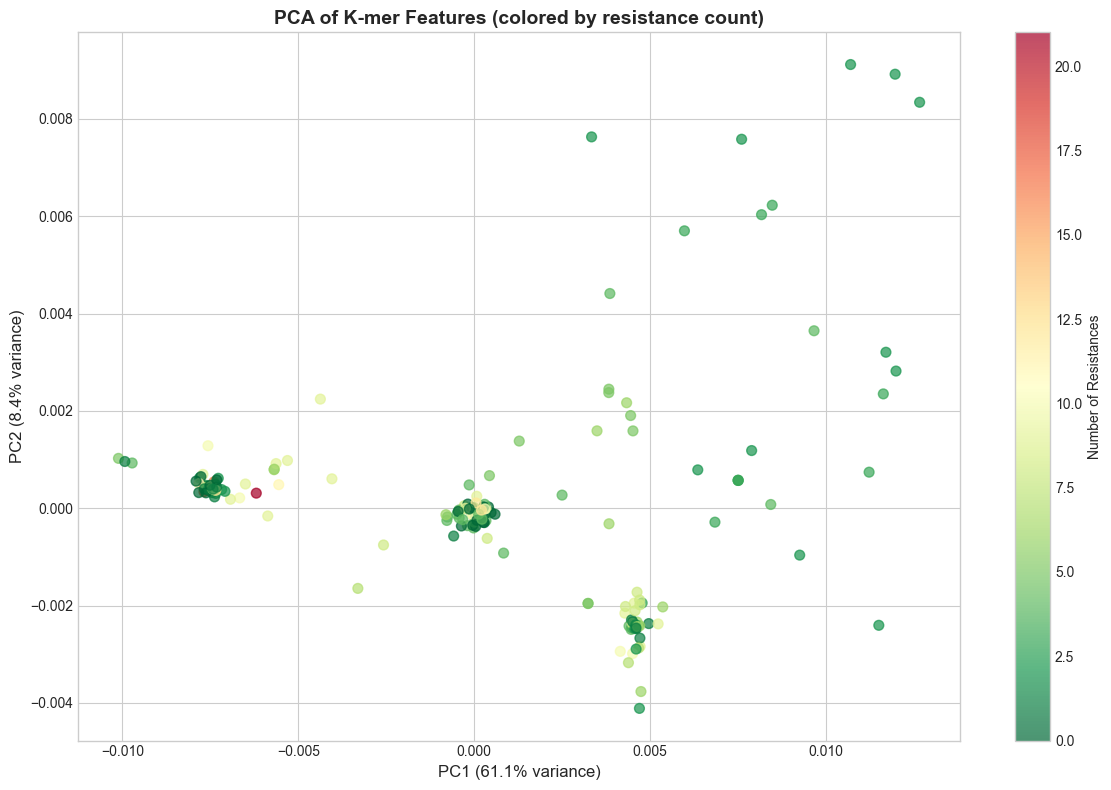

In [36]:
# Color by number of resistances
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_per_sample, 
                     cmap='RdYlGn_r', alpha=0.7, s=50)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA of K-mer Features (colored by resistance count)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Number of Resistances', fontsize=10)

plt.tight_layout()
plt.show()

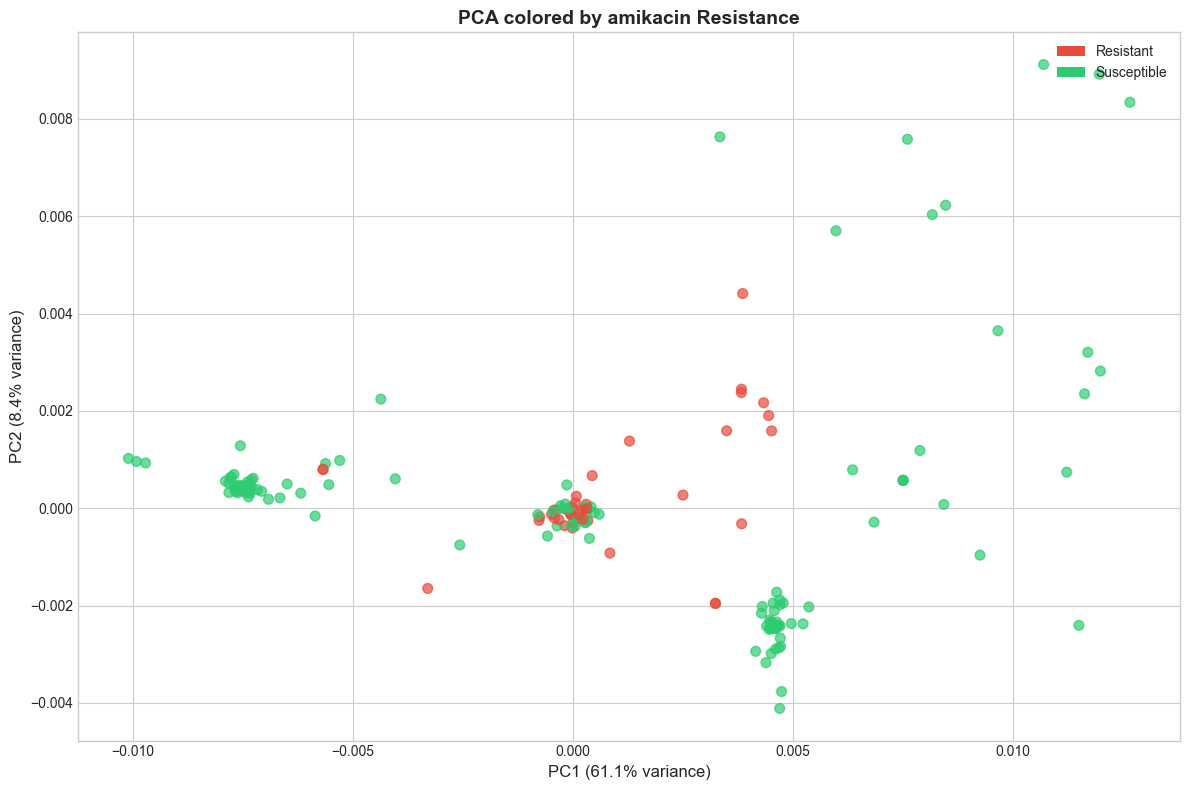

In [37]:
# Color by specific antibiotic resistance (e.g., first one with enough samples)
# Find an antibiotic with good sample distribution
for i, ab in enumerate(class_names[:10]):
    resistant_count = y_train[:, i].sum()
    susceptible_count = len(y_train) - resistant_count
    if resistant_count > 10 and susceptible_count > 10:
        selected_ab_idx = i
        selected_ab = ab
        break

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#2ecc71' if y == 0 else '#e74c3c' for y in y_train[:, selected_ab_idx]]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.7, s=50)

# Create legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Resistant'),
                   Patch(facecolor='#2ecc71', label='Susceptible')]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'PCA colored by {selected_ab} Resistance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Baseline Model Evaluation

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, hamming_loss, accuracy_score

print("Training baseline Random Forest model...")
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training baseline Random Forest model...
Training samples: 189
Validation samples: 27
Test samples: 55


In [39]:
# Train a Random Forest for multi-label classification
rf = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
)

rf.fit(X_train, y_train)
print("Model trained!")

/opt/miniconda3/lib/python3.13/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 19 is present in all training examples.
  warnings.warn(


Model trained!


In [40]:
# Evaluate on validation set
y_val_pred = rf.predict(X_val)

print("=== Validation Set Performance ===")
print(f"Hamming Loss: {hamming_loss(y_val, y_val_pred):.4f}")
print(f"Micro F1: {f1_score(y_val, y_val_pred, average='micro', zero_division=0):.4f}")
print(f"Macro F1: {f1_score(y_val, y_val_pred, average='macro', zero_division=0):.4f}")
print(f"Weighted F1: {f1_score(y_val, y_val_pred, average='weighted', zero_division=0):.4f}")

=== Validation Set Performance ===
Hamming Loss: 0.0801
Micro F1: 0.6296
Macro F1: 0.3718
Weighted F1: 0.5775


In [41]:
# Evaluate on test set
y_test_pred = rf.predict(X_test)

print("=== Test Set Performance ===")
print(f"Hamming Loss: {hamming_loss(y_test, y_test_pred):.4f}")
print(f"Micro F1: {f1_score(y_test, y_test_pred, average='micro', zero_division=0):.4f}")
print(f"Macro F1: {f1_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
print(f"Weighted F1: {f1_score(y_test, y_test_pred, average='weighted', zero_division=0):.4f}")

=== Test Set Performance ===
Hamming Loss: 0.0698
Micro F1: 0.6502
Macro F1: 0.4289
Weighted F1: 0.5974


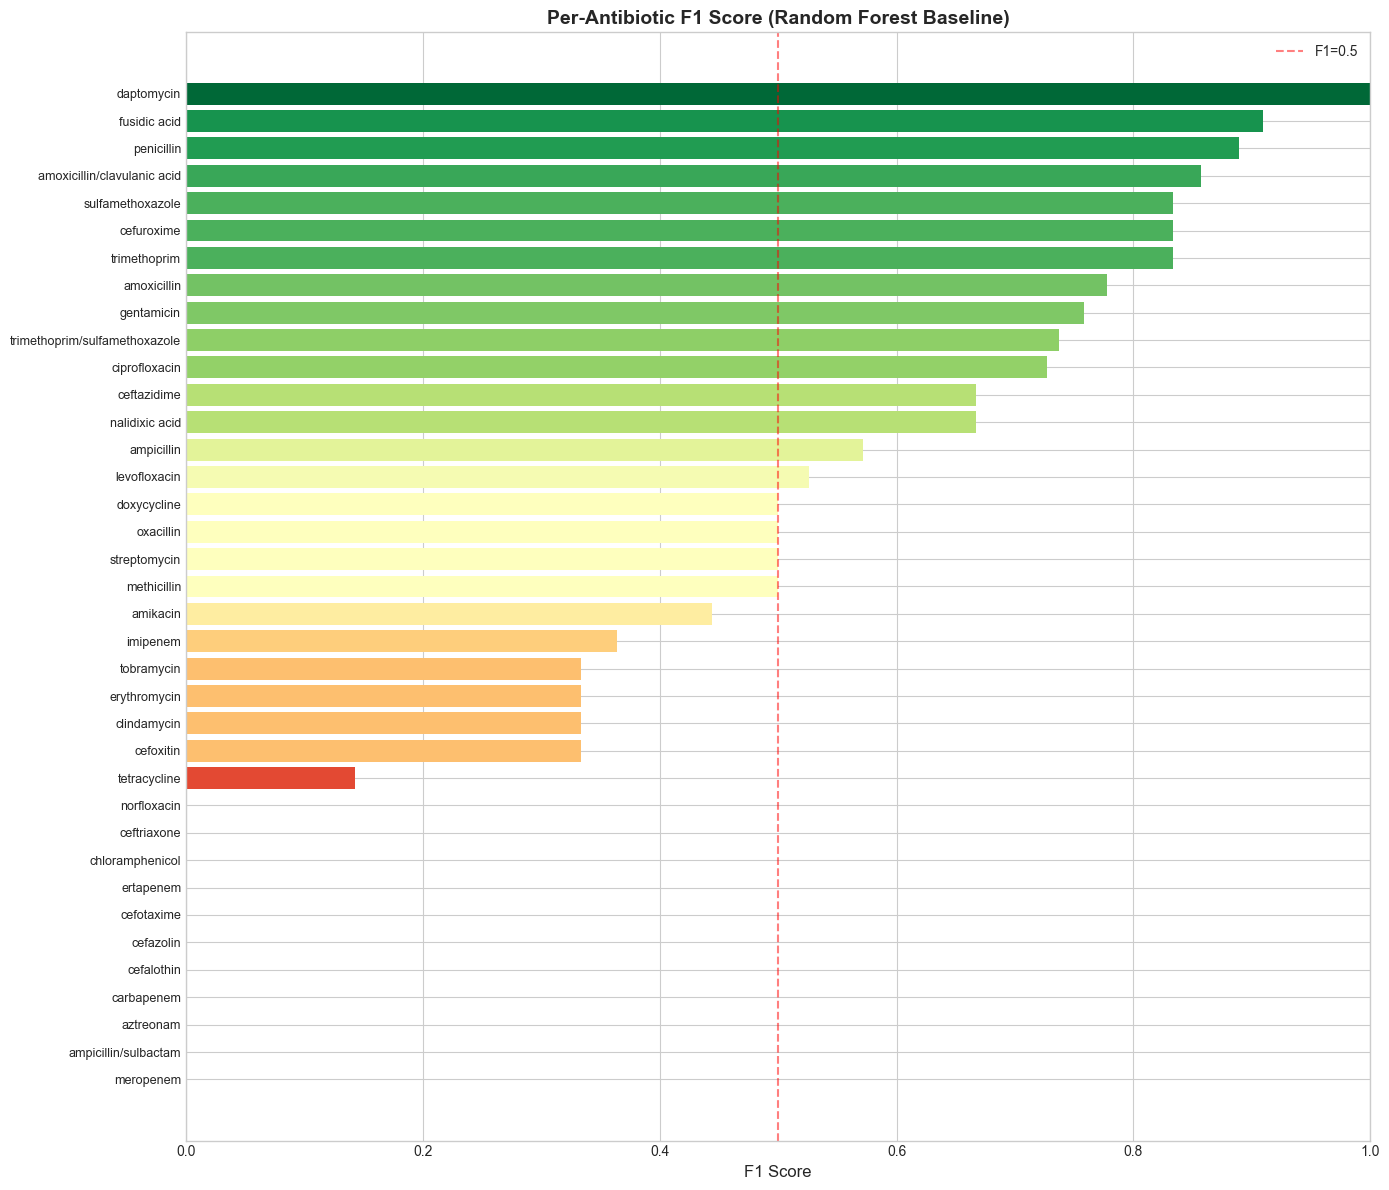

In [42]:
# Per-antibiotic performance
per_class_f1 = f1_score(y_test, y_test_pred, average=None, zero_division=0)

# Sort by F1 score
sorted_idx = np.argsort(per_class_f1)[::-1]

fig, ax = plt.subplots(figsize=(14, 12))

colors = plt.cm.RdYlGn(per_class_f1[sorted_idx])
bars = ax.barh(range(len(class_names)), per_class_f1[sorted_idx], color=colors)
ax.set_yticks(range(len(class_names)))
ax.set_yticklabels([class_names[i] for i in sorted_idx], fontsize=9)
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('Per-Antibiotic F1 Score (Random Forest Baseline)', fontsize=14, fontweight='bold')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='F1=0.5')
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

## 10. Single-Antibiotic Model Performance

In [43]:
# Load single-antibiotic datasets and evaluate
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

single_ab_files = list(PROCESSED_DIR.glob('patric_*_metadata.json'))
single_ab_results = []

for meta_file in single_ab_files:
    if 'multilabel' in str(meta_file):
        continue
    
    prefix = meta_file.stem.replace('_metadata', '')
    
    try:
        X_tr = np.load(PROCESSED_DIR / f'{prefix}_X_train.npy')
        X_te = np.load(PROCESSED_DIR / f'{prefix}_X_test.npy')
        y_tr = np.load(PROCESSED_DIR / f'{prefix}_y_train.npy')
        y_te = np.load(PROCESSED_DIR / f'{prefix}_y_test.npy')
        
        with open(meta_file) as f:
            meta = json.load(f)
        
        # Train simple RF
        clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
        clf.fit(X_tr, y_tr)
        
        y_pred = clf.predict(X_te)
        y_prob = clf.predict_proba(X_te)[:, 1] if len(clf.classes_) == 2 else None
        
        acc = accuracy_score(y_te, y_pred)
        f1 = f1_score(y_te, y_pred, average='binary' if len(np.unique(y_te)) == 2 else 'weighted')
        auc = roc_auc_score(y_te, y_prob) if y_prob is not None else None
        
        single_ab_results.append({
            'antibiotic': meta.get('antibiotic', prefix),
            'n_samples': len(y_tr) + len(y_te),
            'accuracy': acc,
            'f1_score': f1,
            'auc_roc': auc
        })
        
    except Exception as e:
        print(f"Error processing {prefix}: {e}")

results_df = pd.DataFrame(single_ab_results).sort_values('f1_score', ascending=False)
print("Single-Antibiotic Model Performance:")
results_df

Single-Antibiotic Model Performance:


,antibiotic,n_samples,accuracy,f1_score,auc_roc
4,gentamicin,226,0.941176,0.957746,0.961607
3,cefoxitin,159,0.861111,0.918033,0.910714
2,tetracycline,226,0.784314,0.873563,0.643162
0,trimethoprim/sulfamethoxazole,226,0.803922,0.871795,0.815909
1,ciprofloxacin,226,0.843137,0.870968,0.911184


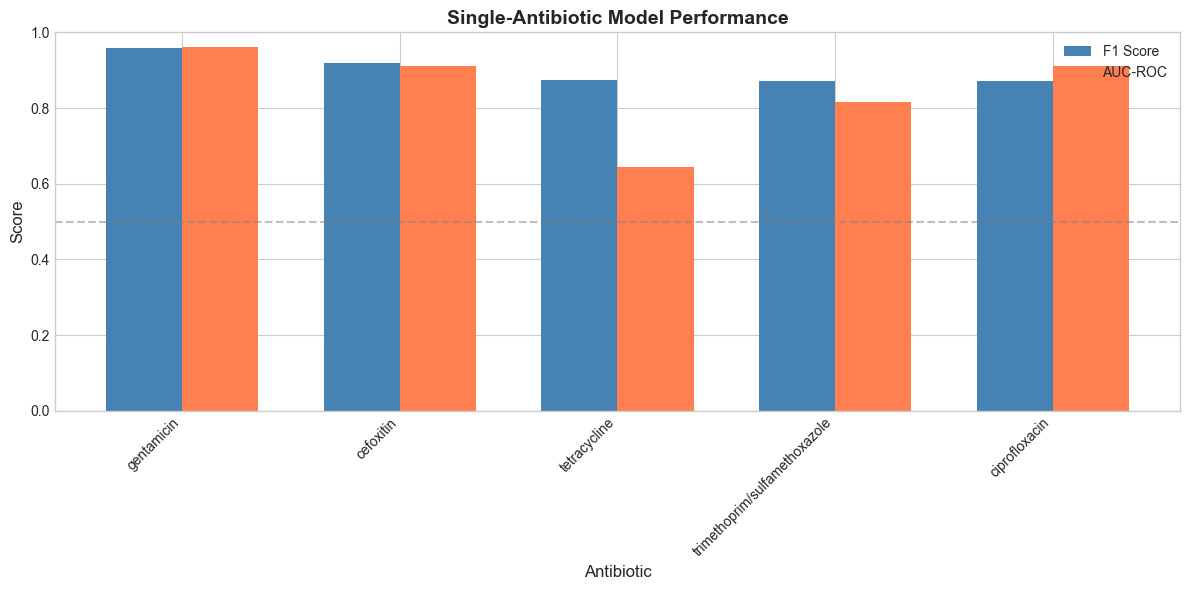

In [44]:
# Visualize single-antibiotic results
if len(results_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = range(len(results_df))
    width = 0.35
    
    ax.bar([i - width/2 for i in x], results_df['f1_score'], width, label='F1 Score', color='steelblue')
    ax.bar([i + width/2 for i in x], results_df['auc_roc'].fillna(0), width, label='AUC-ROC', color='coral')
    
    ax.set_xlabel('Antibiotic', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Single-Antibiotic Model Performance', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['antibiotic'], rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

## Summary

### Key Findings:

1. **Dataset Size**: PATRIC contains phenotypic AMR data for multiple bacterial species

2. **Species Distribution**: Multiple clinically relevant pathogens are represented

3. **Antibiotics**: Wide range of antibiotics tested with varying resistance rates

4. **Features**: DNA 6-mer frequency features capture genomic patterns

5. **Baseline Performance**: Random Forest achieves reasonable performance, with variation across antibiotics

### Next Steps:
- Train deep learning models (CNN, RNN, Transformer)
- Use whole-genome sequence embeddings
- Handle class imbalance with SMOTE or weighted loss
- Incorporate additional features (gene presence/absence, SNPs)
- Combine with CARD data for enhanced predictions